# Regressão Linear Simples e Múltipla

Referência principal: Joel Grus, *Data Science do Zero: Noções Fundamentais com Python*, 2ª ed., Alta Books, 2020.

Objetivo: usar `sklearn.linear_model.LinearRegression` como modelo-base para regressão, interpretação de coeficientes, resíduos e métricas já estudadas: $R^2$, MAE, MSE e RMSE.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Diretórios usados pelo notebook.
FIG_DIR = Path('figures')
DATA_DIR = Path('data')
FIG_DIR.mkdir(exist_ok=True)

# Gerador aleatório fixo para os exemplos sintéticos.
SEED = 42
rng = np.random.default_rng(SEED)

# Configuração visual padronizada para todas as figuras exportadas.
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 220,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def metricas(y_true, y_pred):
    # Calcula as métricas já discutidas em aula.
    mse = mean_squared_error(y_true, y_pred)
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
    }


## Formulação

### Regressão linear simples

$$
\hat{y}_i = \beta_0 + \beta_1 x_i
$$

### Regressão linear múltipla

Para uma amostra $i$ com $p$ variáveis de entrada:

$$
\hat{y}_i
= \beta_0
+ \beta_1 x_{i,1}
+ \beta_2 x_{i,2}
+ \cdots
+ \beta_p x_{i,p}.
$$

Em forma matricial:

$$
\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}.
$$

### Ajuste por mínimos quadrados

Os parâmetros são escolhidos para minimizar a soma dos quadrados dos resíduos:

$$
\boldsymbol{\beta}^{\star}
=
\arg\min_{\boldsymbol{\beta}}
\sum_{i=1}^{n}
\left(
y_i - \hat{y}_i
\right)^2.
$$

O resíduo da amostra $i$ é:

$$
e_i = y_i - \hat{y}_i.
$$

## Exemplo: estimação de resistência

Em um ensaio de bancada com resistor, a Lei de Ohm impõe uma relação linear entre tensão e corrente:

$$
V_i = R I_i.
$$

Para respeitar a física do problema, ajustamos a regressão sem intercepto:

$$
\widehat{V}_i = \widehat{R} I_i.
$$

Aqui o coeficiente estimado pela regressão é a própria resistência elétrica $\widehat{R}$, em ohms.

In [4]:
# Ensaio sintético de um resistor de 47 ohms.
n = 60
resistencia_real = 47.0  # ohms
corrente = np.linspace(0.01, 0.20, n)  # A
# Usa a mesma semente definida na primeira célula para deixar este exemplo reprodutível.
rng_resistencia = np.random.default_rng(SEED)
ruido_medicao = rng_resistencia.normal(0, 0.18, n)  # V
tensao = resistencia_real * corrente + ruido_medicao

# fit_intercept=False força a reta a passar pela origem, como exige V = R I.
X_simples = corrente.reshape(-1, 1)
modelo_simples = LinearRegression(fit_intercept=False).fit(X_simples, tensao)
pred_simples = modelo_simples.predict(X_simples)
residuos_simples = tensao - pred_simples
resistencia_estimada = modelo_simples.coef_[0]

print(f'Resistência real: {resistencia_real:.2f} ohms')
print(f'Resistência estimada: {resistencia_estimada:.2f} ohms')
print(metricas(tensao,pred_simples))

Resistência real: 47.00 ohms
Resistência estimada: 47.13 ohms
{'R2': 0.9971837262449934, 'MAE': 0.11451882927873219, 'MSE': 0.01956472269643068, 'RMSE': 0.13987395288770058}


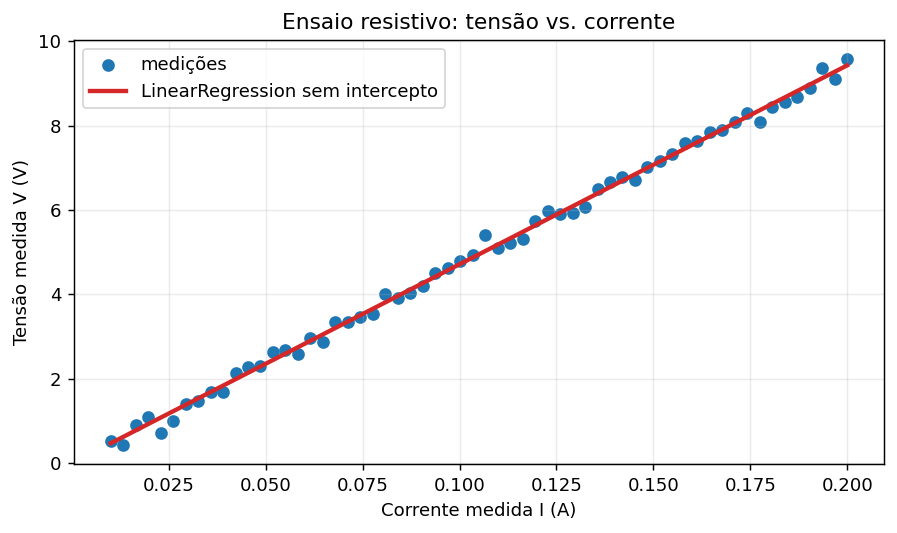

In [5]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.scatter(corrente, tensao, color='#1f77b4', label='medições', s=36)
ax.plot(corrente, pred_simples, color='#d62728', linewidth=2.4, label='LinearRegression sem intercepto')
ax.set_title('Ensaio resistivo: tensão vs. corrente')
ax.set_xlabel('Corrente medida I (A)')
ax.set_ylabel('Tensão medida V (V)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'aula10_regressao_simples.png', bbox_inches='tight')
plt.show()

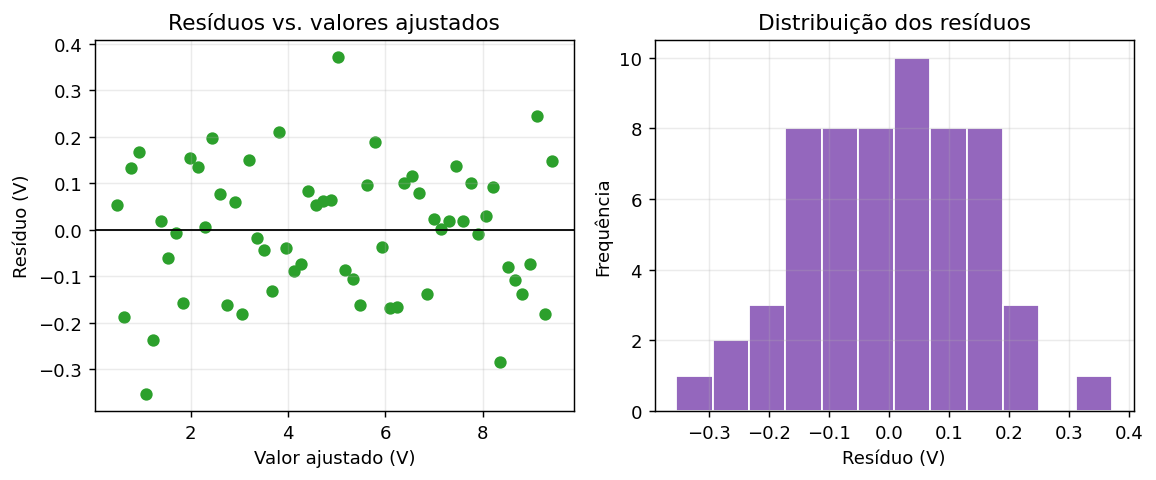

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
axes[0].axhline(0, color='black', linewidth=1)
axes[0].scatter(pred_simples, residuos_simples, color='#2ca02c', s=34)
axes[0].set_title('Resíduos vs. valores ajustados')
axes[0].set_xlabel('Valor ajustado (V)')
axes[0].set_ylabel('Resíduo (V)')
axes[1].hist(residuos_simples, bins=12, color='#9467bd', edgecolor='white')
axes[1].set_title('Distribuição dos resíduos')
axes[1].set_xlabel('Resíduo (V)')
axes[1].set_ylabel('Frequência')
fig.tight_layout()
fig.savefig(FIG_DIR / 'aula10_residuos_simples.png', bbox_inches='tight')
plt.show()

## Exemplo real: usina de ciclo combinado

Dataset: **Combined Cycle Power Plant**, UCI Machine Learning Repository.

Fonte: https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant

O conjunto contém 9568 registros coletados por 6 anos (2006-2011), com a usina operando em plena carga. As entradas são variáveis ambientais médias horárias: temperatura ambiente (`AT`), vácuo de exaustão (`V`), pressão ambiente (`AP`) e umidade relativa (`RH`). A saída é a potência elétrica líquida horária (`PE`), em MW.

Este é um bom exemplo para regressão linear porque as variáveis ambientais afetam fisicamente o desempenho de turbinas e, no domínio observado, o modelo linear explica grande parte da variação de potência.

In [7]:
# O arquivo foi simplificado para um único CSV zipado em data/.
ccpp_path = DATA_DIR / 'combined_cycle_power_plant.csv.zip'

# Leitura direta do zip pelo pandas, sem descompactar manualmente.
ccpp = pd.read_csv(ccpp_path, compression='zip')

print(ccpp.head())
print(ccpp.describe().round(2))

      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90
            AT        V       AP       RH       PE
count  9568.00  9568.00  9568.00  9568.00  9568.00
mean     19.65    54.31  1013.26    73.31   454.37
std       7.45    12.71     5.94    14.60    17.07
min       1.81    25.36   992.89    25.56   420.26
25%      13.51    41.74  1009.10    63.33   439.75
50%      20.34    52.08  1012.94    74.97   451.55
75%      25.72    66.54  1017.26    84.83   468.43
max      37.11    81.56  1033.30   100.16   495.76


PE = 497.193 + (-2.179) AT
Teste - modelo simples AT -> PE
  R2: 0.8987
  MAE: 4.2745 MW
  MSE: 29.4481 MW^2
  RMSE: 5.4266 MW


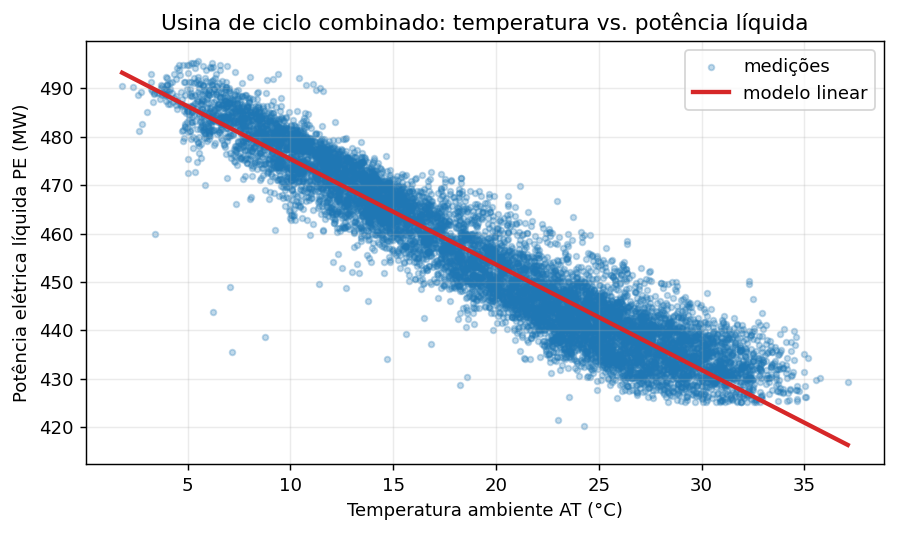

In [16]:
X_at = ccpp[['AT']].to_numpy()
y_pe = ccpp['PE'].to_numpy()
X_train_at, X_test_at, y_train_pe, y_test_pe = train_test_split(X_at, y_pe, test_size=0.25, random_state=42)
modelo_at = LinearRegression().fit(X_train_at, y_train_pe)
pred_at = modelo_at.predict(X_test_at)

print(f'PE = {modelo_at.intercept_:.3f} + ({modelo_at.coef_[0]:.3f}) AT')
metricas_at = metricas(y_test_pe, pred_at)
print('Teste - modelo simples AT -> PE')
print(f"  R2: {metricas_at['R2']:.4f}")
print(f"  MAE: {metricas_at['MAE']:.4f} MW")
print(f"  MSE: {metricas_at['MSE']:.4f} MW^2")
print(f"  RMSE: {metricas_at['RMSE']:.4f} MW")

ordem = np.argsort(X_at[:, 0])
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.scatter(ccpp['AT'], ccpp['PE'], s=10, alpha=0.28, color='#1f77b4', label='medições')
ax.plot(X_at[ordem, 0], modelo_at.predict(X_at[ordem]), color='#d62728', linewidth=2.4, label='modelo linear')
ax.set_title('Usina de ciclo combinado: temperatura vs. potência líquida')
ax.set_xlabel('Temperatura ambiente AT (°C)')
ax.set_ylabel('Potência elétrica líquida PE (MW)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'aula10_ccpp_at_pe.png', bbox_inches='tight')
plt.show()

In [17]:
features_ccpp = ['AT', 'V', 'AP', 'RH']
X = ccpp[features_ccpp].to_numpy()
y = ccpp['PE'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
modelo_ccpp = LinearRegression().fit(X_train, y_train)
pred_train = modelo_ccpp.predict(X_train)
pred_test = modelo_ccpp.predict(X_test)
residuos_ccpp = y_test - pred_test

print(f'Intercepto beta0: {modelo_ccpp.intercept_:.4f} MW')
for nome, coef in zip(features_ccpp, modelo_ccpp.coef_):
    print(f'{nome:3s}: {coef: .4f}')
print()
metricas_train_ccpp = metricas(y_train, pred_train)
metricas_test_ccpp = metricas(y_test, pred_test)

print('Treino - CCPP')
print(f"  R2: {metricas_train_ccpp['R2']:.4f}")
print(f"  MAE: {metricas_train_ccpp['MAE']:.4f} MW")
print(f"  MSE: {metricas_train_ccpp['MSE']:.4f} MW^2")
print(f"  RMSE: {metricas_train_ccpp['RMSE']:.4f} MW")

print('\nTeste - CCPP')
print(f"  R2: {metricas_test_ccpp['R2']:.4f}")
print(f"  MAE: {metricas_test_ccpp['MAE']:.4f} MW")
print(f"  MSE: {metricas_test_ccpp['MSE']:.4f} MW^2")
print(f"  RMSE: {metricas_test_ccpp['RMSE']:.4f} MW")

Intercepto beta0: 459.6790 MW
AT : -1.9959
V  : -0.2289
AP :  0.0572
RH : -0.1587

Treino - CCPP
  R2: 0.9285
  MAE: 3.6337 MW
  MSE: 20.8369 MW^2
  RMSE: 4.5647 MW

Teste - CCPP
  R2: 0.9292
  MAE: 3.5858 MW
  MSE: 20.5819 MW^2
  RMSE: 4.5367 MW


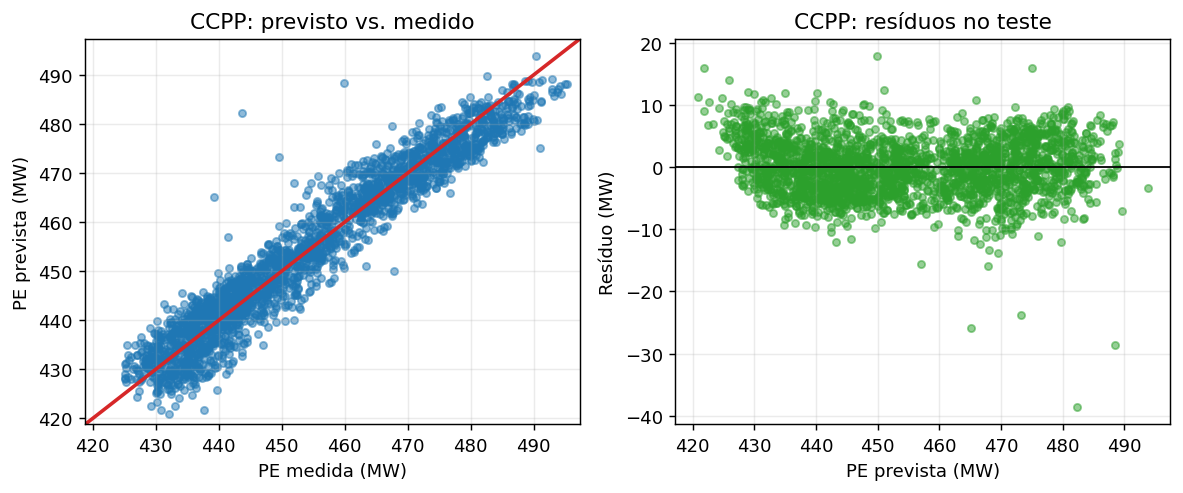

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.9))
axes[0].scatter(y_test, pred_test, s=16, alpha=0.5, color='#1f77b4')
limites = [min(y_test.min(), pred_test.min()) - 2, max(y_test.max(), pred_test.max()) + 2]
axes[0].plot(limites, limites, color='#d62728', linewidth=2)
axes[0].set_xlim(limites)
axes[0].set_ylim(limites)
axes[0].set_title('CCPP: previsto vs. medido')
axes[0].set_xlabel('PE medida (MW)')
axes[0].set_ylabel('PE prevista (MW)')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].scatter(pred_test, residuos_ccpp, s=16, alpha=0.5, color='#2ca02c')
axes[1].set_title('CCPP: resíduos no teste')
axes[1].set_xlabel('PE prevista (MW)')
axes[1].set_ylabel('Resíduo (MW)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'aula10_ccpp_predito_residuos.png', bbox_inches='tight')
plt.show()

## Exemplo real: previsão temporal de consumo elétrico

Dataset: **Individual Household Electric Power Consumption**, UCI Machine Learning Repository.

Fonte: https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

Aqui a regressão linear múltipla é usada como modelo-base de previsão de série temporal. A tarefa é prever a potência ativa global no próximo intervalo de 10 minutos usando valores recentes da própria série, uma defasagem diária, médias móveis e a hora do dia codificada de forma cíclica.

### Modelo usado na previsão um passo à frente

Queremos prever a potência ativa no próximo intervalo de 10 min:

$$
\begin{aligned}
\widehat{P}_{t+1}=\beta_0
&+\beta_1P_t+\beta_2P_{t-1}+\beta_3P_{t-2}
+\beta_4P_{t-6}+\beta_5P_{t-144}\\
&+\beta_6\overline{P}_{1h}+\beta_7\overline{P}_{24h}
+\beta_8\sin\left(\frac{2\pi h_t}{24}\right)
+\beta_9\cos\left(\frac{2\pi h_t}{24}\right).
\end{aligned}
$$

- $P_t$: potência medida agora.
- $P_{t-1}$, $P_{t-2}$: passado recente.
- $P_{t-6}$: aproximadamente 1 hora antes.
- $P_{t-144}$: aproximadamente 24 horas antes.
- $\overline{P}_{1h}$: média da potência na última hora.
- $\overline{P}_{24h}$: média da potência nas últimas 24 horas.
- $\sin(2\pi h_t/24)$, $\cos(2\pi h_t/24)$: codificam a hora como ciclo diário.


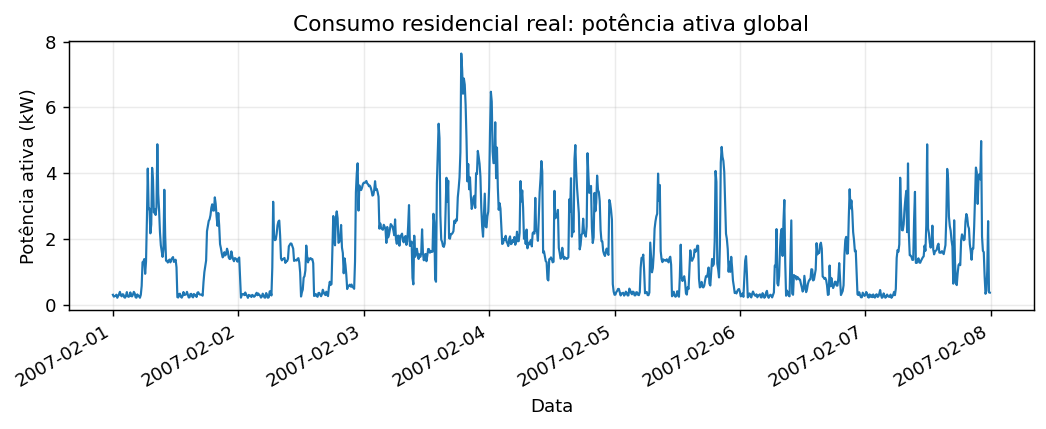

       Global_active_power    Voltage  Global_intensity
count            25690.000  25690.000         25690.000
mean                 1.165    239.209             4.975
std                  1.128      3.515             4.767
min                  0.084    225.701             0.400
25%                  0.299    236.670             1.340
50%                  0.657    239.630             2.900
75%                  1.644    241.780             6.960
max                  8.532    249.992            36.980


In [20]:
# Dataset UCI já salvo como zip diretamente na pasta data/.
household_zip = DATA_DIR / 'household_power_consumption.zip'

numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
]

# O zip contém um único arquivo texto; o pandas lê diretamente com compression='zip'.
household_raw = pd.read_csv(
    household_zip,
    sep=';',
    na_values='?',
    low_memory=False,
    compression='zip',
)

# Cria índice temporal e converte colunas numéricas.
household_raw['datetime'] = pd.to_datetime(
    household_raw['Date'] + ' ' + household_raw['Time'],
    dayfirst=True,
    errors='coerce',
)
for col in numeric_cols:
    household_raw[col] = pd.to_numeric(household_raw[col], errors='coerce')

# Reamostra para 10 minutos e usa uma janela curta para manter a execução leve.
household_10min = (
    household_raw
    .dropna(subset=['datetime'] + numeric_cols)
    .set_index('datetime')[numeric_cols]
    .resample('10min')
    .mean()
    .dropna()
    .loc['2007-01-01':'2007-06-30']
    .copy()
)

# Figura de contexto: uma semana real de potência ativa residencial.
fig, ax = plt.subplots(figsize=(8.2, 3.4))
trecho = household_10min.loc['2007-02-01':'2007-02-07', 'Global_active_power']
ax.plot(trecho.index, trecho, color='#1f77b4', linewidth=1.2)
ax.set_title('Consumo residencial real: potência ativa global')
ax.set_xlabel('Data')
ax.set_ylabel('Potência ativa (kW)')
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / 'aula10_household_serie.png', bbox_inches='tight')
plt.show()

print(household_10min[['Global_active_power', 'Voltage', 'Global_intensity']].describe().round(3))

In [23]:
# Monta uma tabela supervisionada a partir da série temporal.
ts = household_10min.copy()
p = ts['Global_active_power']

# Variáveis defasadas: passado recente e comportamento no mesmo horário do dia anterior.
ts['P_t'] = p
ts['P_t_menos_1'] = p.shift(1)
ts['P_t_menos_2'] = p.shift(2)
ts['P_t_menos_6'] = p.shift(6)       # 1 hora antes, pois a resolução é de 10 min
ts['P_t_menos_144'] = p.shift(144)   # 24 horas antes

# Médias móveis para representar tendência local.
ts['media_1h'] = p.rolling(6).mean()
ts['media_24h'] = p.rolling(144).mean()

# Codificação cíclica da hora do dia.
hora_decimal = ts.index.hour + ts.index.minute / 60
ts['hora_sin'] = np.sin(2 * np.pi * hora_decimal / 24)
ts['hora_cos'] = np.cos(2 * np.pi * hora_decimal / 24)

# Alvo: potência ativa no próximo intervalo de 10 minutos.
ts['P_t_mais_1'] = p.shift(-1)

features_ts = [
    'P_t',
    'P_t_menos_1',
    'P_t_menos_2',
    'P_t_menos_6',
    'P_t_menos_144',
    'media_1h',
    'media_24h',
    'hora_sin',
    'hora_cos',
]
target_ts = 'P_t_mais_1'
dados_ts = ts[features_ts + [target_ts]].dropna()

# Separação temporal: treino no início da série, teste no final.
split = int(0.70 * len(dados_ts))
train_ts = dados_ts.iloc[:split]
test_ts = dados_ts.iloc[split:]

modelo_ts = LinearRegression().fit(train_ts[features_ts], train_ts[target_ts])
pred_ts = modelo_ts.predict(test_ts[features_ts])
residuos_ts = test_ts[target_ts].to_numpy() - pred_ts

metricas_ts = metricas(test_ts[target_ts], pred_ts)
print('Teste - previsão temporal de potência ativa')
print(f"  R2: {metricas_ts['R2']:.4f}")
print(f"  MAE: {metricas_ts['MAE']:.4f} kW")
print(f"  MSE: {metricas_ts['MSE']:.4f} kW^2")
print(f"  RMSE: {metricas_ts['RMSE']:.4f} kW")

coef_ts = pd.Series(modelo_ts.coef_, index=features_ts).sort_values(key=np.abs, ascending=False)
print('\nCoeficientes ordenados por magnitude:')
print(coef_ts.round(4))

Teste - previsão temporal de potência ativa
  R2: 0.6995
  MAE: 0.2699 kW
  MSE: 0.2497 kW^2
  RMSE: 0.4997 kW

Coeficientes ordenados por magnitude:
P_t              0.8808
P_t_menos_1     -0.0864
P_t_menos_2      0.0637
P_t_menos_6      0.0485
media_24h        0.0389
P_t_menos_144    0.0322
hora_sin        -0.0298
hora_cos        -0.0186
media_1h        -0.0157
dtype: float64


### Configuração do experimento temporal

- Resolução após reamostragem: 10 min.
- Janela usada: jan.--jun. de 2007.
- Separação: treino, teste.
- Métricas em teste: $R^2 = 0{,}6995$, MAE = 0,2699 kW, RMSE = 0,4997 kW.

O modelo usa persistência, comportamento diário e médias móveis para prever o próximo valor da série.


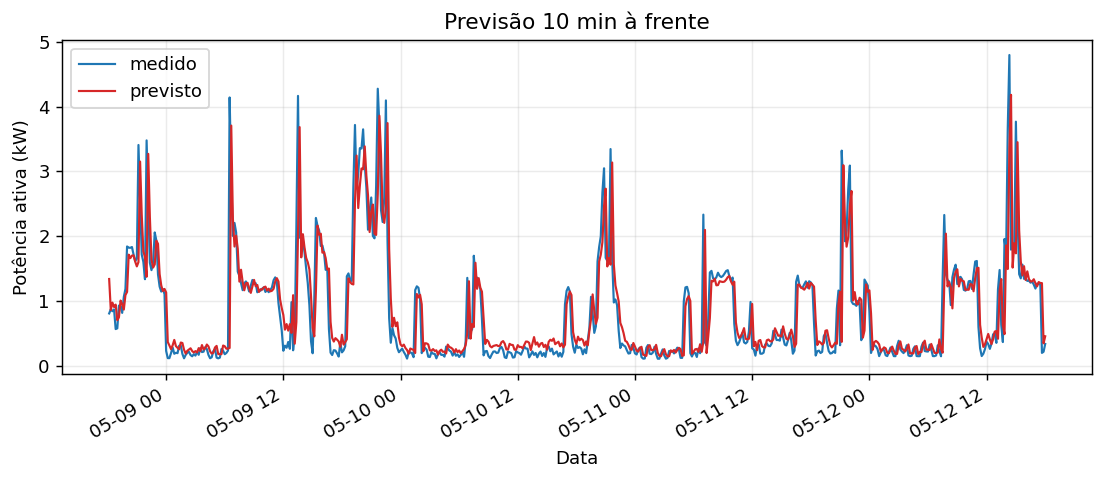

In [24]:
# Janela comum para comparar previsão um passo à frente e predição livre.
freq_ts = pd.Timedelta('10min')
janela_previsao = 6 * 24 * 4  # quatro dias em resolução de 10 min
origens_previsao = test_ts.index[:janela_previsao]
tempo_previsao = origens_previsao + freq_ts

# Evolução temporal da previsão um passo à frente.
fig, ax = plt.subplots(figsize=(8.6, 3.8))
ax.plot(
    tempo_previsao,
    test_ts[target_ts].iloc[:janela_previsao],
    label='medido',
    color='#1f77b4',
    linewidth=1.2,
)
ax.plot(
    tempo_previsao,
    pred_ts[:janela_previsao],
    label='previsto',
    color='#d62728',
    linewidth=1.2,
)
ax.set_title('Previsão 10 min à frente')
ax.set_xlabel('Data')
ax.set_ylabel('Potência ativa (kW)')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / 'aula10_household_previsao_temporal_serie.png', bbox_inches='tight')
plt.show()

### Previsão um passo à frente

Na avaliação anterior, usamos previsão **um passo à frente**:

$$
\widehat{P}_{t+1}=f(P_t, P_{t-1}, P_{t-2}, P_{t-6}, P_{t-144}, \ldots).
$$

- As entradas vêm da série medida até o instante $t$.
- A cada novo passo, o modelo recebe novamente dados reais.
- É adequada quando o sistema será atualizado continuamente por medições.

Característica: o erro de uma previsão não contamina diretamente a próxima entrada do modelo.


### Predição livre

Na **predição livre**, o modelo é colocado para evoluir sozinho:

$$
\widehat{P}_{t+2}=f(\widehat{P}_{t+1}, P_t, P_{t-1}, P_{t-5}, P_{t-143}, \ldots).
$$

- Depois do primeiro passo, previsões anteriores entram como novas entradas.
- É útil para simular vários passos à frente sem novas medições.
- Pequenos erros podem se acumular ao longo do tempo.

Importante: o desempenho costuma ser pior que na previsão um passo à frente. Forma mais robusta de testar a qualidade do modelo.


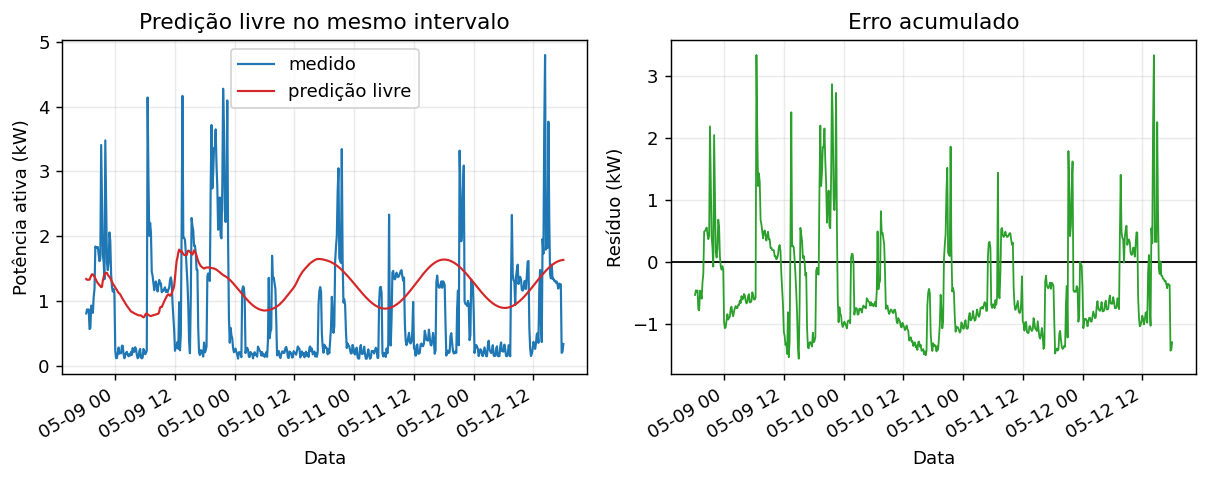

In [26]:
# Predição livre: depois do primeiro passo, o modelo usa as próprias previsões.
serie_recursiva = household_10min['Global_active_power'].copy()
pred_livre = []

for origem in origens_previsao:
    hora_decimal = origem.hour + origem.minute / 60

    # Features calculadas a partir da série recursiva, não da série real futura.
    x_livre = pd.DataFrame([{
        'P_t': serie_recursiva.loc[origem],
        'P_t_menos_1': serie_recursiva.loc[origem - freq_ts],
        'P_t_menos_2': serie_recursiva.loc[origem - 2 * freq_ts],
        'P_t_menos_6': serie_recursiva.loc[origem - 6 * freq_ts],
        'P_t_menos_144': serie_recursiva.loc[origem - 144 * freq_ts],
        'media_1h': serie_recursiva.loc[origem - 5 * freq_ts:origem].mean(),
        'media_24h': serie_recursiva.loc[origem - 143 * freq_ts:origem].mean(),
        'hora_sin': np.sin(2 * np.pi * hora_decimal / 24),
        'hora_cos': np.cos(2 * np.pi * hora_decimal / 24),
    }], columns=features_ts)

    proximo_tempo = origem + freq_ts
    proxima_potencia = float(modelo_ts.predict(x_livre)[0])

    # Realimenta a previsão para que passos seguintes não usem medições futuras.
    serie_recursiva.loc[proximo_tempo] = proxima_potencia
    pred_livre.append(proxima_potencia)

pred_livre = np.array(pred_livre)
real_livre = household_10min.loc[tempo_previsao, 'Global_active_power'].to_numpy()
residuos_livre = real_livre - pred_livre

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8))

# Mesmo timeframe da previsão um passo à frente.
axes[0].plot(tempo_previsao, real_livre, label='medido', color='#1f77b4', linewidth=1.2)
axes[0].plot(tempo_previsao, pred_livre, label='predição livre', color='#d62728', linewidth=1.2)
axes[0].set_title('Predição livre no mesmo intervalo')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Potência ativa (kW)')
axes[0].legend()

# Erro ao longo do tempo: aqui fica visível o acúmulo de erro.
axes[1].axhline(0, color='black', linewidth=1)
axes[1].plot(tempo_previsao, residuos_livre, color='#2ca02c', linewidth=1.0)
axes[1].set_title('Erro acumulado')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Resíduo (kW)')

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / 'aula10_household_predicao_livre.png', bbox_inches='tight')
plt.show()

### Leitura da predição livre

No mesmo intervalo da previsão um passo à frente, a predição livre acumula erro porque previsões anteriores entram como novas entradas do modelo.


## Pontos para discussão

- No exemplo CCPP, a regressão linear múltipla é uma estimativa estática de potência líquida a partir de condições ambientais; não é uma predição temporal.
- O modelo CCPP é válido no domínio observado: extrapolações fora das faixas medidas não são garantidas.
- Na série temporal residencial, a previsão um passo à frente usa medições reais até o instante atual.
- Na predição livre, previsões anteriores entram como novas entradas e o erro pode se acumular.